In [209]:
from typing import TypedDict, List
import random
from langgraph.graph import StateGraph, END

In [210]:
class GameState(TypedDict):
    name: str           #Вводит юзер
    guesses: List[int]
    max_counter: int    #Вводит юзер
    counter: int
    lower_bound: int    #Вводит юзер
    upper_bound: int    #Вводит юзер
    right_answer: int

In [211]:
def set_up_node(state: GameState)-> GameState:
    """Sets up the game"""
    print("Hi there,", state["name"], ", I'll play a game")
    state['counter'] = 0
    state['guesses'] = []
    state['right_answer'] = random.randint(state['lower_bound'], state['upper_bound'])
    return state

def guess_node(state: GameState)-> GameState:
    """Generates a random num from lower bound to lower bound"""
    state['guesses'].append(random.randint(state['lower_bound'], state['upper_bound']))
    state['counter'] += 1
    print("This is my", state['counter'], "out of", state['max_counter'], "guess and I guess it is", state['guesses'][-1])
    return state

def should_countinue(state: GameState)->bool:
    if state['guesses'][-1] == state["right_answer"]:
        print("Yes, I've guessed the number! It is", state['guesses'][-1])
        return False
    elif state['counter'] < state['max_counter']:
        return True
    else:
        print("Sorry, I ran out of tries")
        return False

def hint_node(state: GameState)-> GameState:
    """Changes bounds"""
    if state['guesses'][-1] < state["right_answer"]:
        print("It looks like the right answer is bigger...")
        state['lower_bound'] = state['guesses'][-1] + 1
    else:
        print("It looks like the right answer is smaller...")
        state['upper_bound'] = state['guesses'][-1] - 1
    return state
    

In [212]:
graph = StateGraph(GameState)
graph.add_node("set_up_node", set_up_node)
graph.add_node("guess_node", guess_node)
graph.add_node("hint_node", hint_node)
graph.set_entry_point("set_up_node")
graph.add_edge("set_up_node", "guess_node")
graph.add_conditional_edges("guess_node", should_countinue, {True: "hint_node", False: END})
graph.add_edge("hint_node", "guess_node")
app = graph.compile()

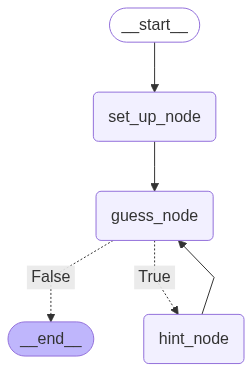

In [213]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [294]:
print(app.invoke({"name": "Yana", "max_counter": 15, "lower_bound": 100, "upper_bound": 300 }, {"recursion_limit": 100}))

Hi there, Yana , I'll play a game
This is my 1 out of 15 guess and I guess it is 211
It looks like the right answer is smaller...
This is my 2 out of 15 guess and I guess it is 135
It looks like the right answer is bigger...
This is my 3 out of 15 guess and I guess it is 172
It looks like the right answer is bigger...
This is my 4 out of 15 guess and I guess it is 173
It looks like the right answer is bigger...
This is my 5 out of 15 guess and I guess it is 189
It looks like the right answer is bigger...
This is my 6 out of 15 guess and I guess it is 190
It looks like the right answer is bigger...
This is my 7 out of 15 guess and I guess it is 194
It looks like the right answer is bigger...
This is my 8 out of 15 guess and I guess it is 200
It looks like the right answer is bigger...
This is my 9 out of 15 guess and I guess it is 209
It looks like the right answer is smaller...
This is my 10 out of 15 guess and I guess it is 208
It looks like the right answer is smaller...
This is my 1